# Triggering

You can trigger the acquisition using an external source (TTL signal).

There are three acquisition trigger modes (the `trigger_start` argument of the `start()` method):
- “soft” mode (the default mode): the acquisition is triggered by the software;
- “trig1” mode: acquisition is put on hold until an external trigger signal is received on the hub’s `TRIG` or `TRIG 1` port (models >= Mµ128);
- “trig2” mode: the acquisition waits for an external trigger signal on the hub's `TRIG 2` port (models >= Mµ128).

The external trigger mode accepts 4 parameters specified by `trigger_start_mode` (default `“rising”`):
- “rising”: trigger on the rising edge of the trigger signal
- “falling”: trigger on the falling edge of the trigger signal
- “high”: trigger on the high level of the trigger signal
- “low”: trigger on the low level of the trigger signal

In this Notebook, we provide examples of programming acquisitions with triggers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros import Megamicros, AcquisitionConfig
from notebooks_tools import plot_signal

# Set log level to INFO to see device detection details
log.setLevel("INFO")

antenna = Megamicros()

2026-04-23 11:25:39,582 [INFO]: Creating UsbDataSource (0xfe27:0xac04)
2026-04-23 11:25:39,583 [INFO]: UsbDataSource initialized: 64 MEMS available


## Triggering with Megamicros

In the example below, we set the acquisition to “trig1/rising” mode for 1 second with a 60-second timeout (which gives us 60 seconds to send the TRIG signal).
The `ATT. TRIG` LED should turn on, then turn off as soon as the `TRIG` signal is received. The `DATA` acquisition LED should then remain on for the entire acquisition duration (1 second).

2026-04-23 11:26:44,002 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-23 11:26:44,007 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-23 11:26:44,008 [INFO]: Sampling frequency 50000Hz sent as clockdiv 9 (nearest activated frequency is 50000Hz)
2026-04-23 11:26:44,010 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-23 11:26:44,010 [INFO]: Datatype sent to FPGA: int32
2026-04-23 11:26:44,011 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-23 11:26:44,011 [INFO]: Starting USB acquisition...
2026-04-23 11:26:44,012 [INFO]: START command sent to FPGA (trigger: trig1, mode: rising)
2026-04-23 11:26:44,013 [INFO]: Starting native USB async bulk transfer (duration=1.0s, expected frames=49)
2026-04-23 11:26:44,013 [INFO]: Init asynchronous bulk transfer...
2026-04-23 11:26:44,014 [INFO]: Starting asynchronous bulk transfer thread...
2026-04-23 11:26:44,014 [INFO]: (Async bulk THREAD) Transfer thread ex

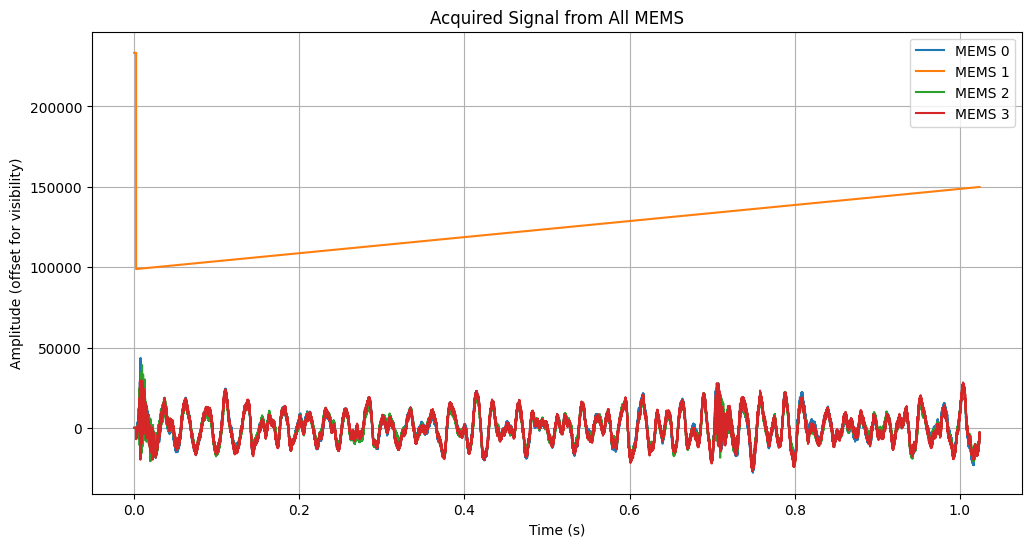

In [3]:
# Create configuration object
config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    sampling_frequency=50000,
    frame_length=1024,
    duration=1.0,
    timeout=10,
    trigger_start='trig1', 
    trigger_start_mode='rising'
)

# Use configuration (unpack dict)
try:
    antenna.run(**config.__dict__)

    # Collect signal
    frames = []
    for frame in antenna:
        frames.append(frame)

    antenna.wait()
    antenna.stop()

    # Concatenate all frames
    signal = np.concatenate(frames, axis=1)[1:,:]  # Skip counter row

    # Display signal
    plot_signal(signal, config.sampling_frequency)
    
except Exception as e:
    log.error(f"An error occurred during acquisition: {e}")

You can also stop the acquisition by using an external trigger signal provided you set the `trigger_stop` parameter (see details below in the *USB Source part*):

2026-04-23 11:27:20,786 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-23 11:27:20,789 [INFO]: USB callback: transfer cancelled
2026-04-23 11:27:20,790 [INFO]: USB callback: transfer cancelled
2026-04-23 11:27:20,790 [INFO]: USB callback: transfer cancelled
2026-04-23 11:27:20,791 [INFO]: USB callback: transfer cancelled
2026-04-23 11:27:20,791 [INFO]: USB callback: transfer cancelled
2026-04-23 11:27:20,792 [INFO]: USB callback: transfer cancelled
2026-04-23 11:27:20,793 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-23 11:27:20,794 [INFO]: Sampling frequency 50000Hz sent as clockdiv 9 (nearest activated frequency is 50000Hz)
2026-04-23 11:27:20,795 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-23 11:27:20,796 [INFO]: Datatype sent to FPGA: int32
2026-04-23 11:27:20,797 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-23 11:27:20,797 [INFO]: Starting USB acquisition...
2026-04-23 11:27:20,798

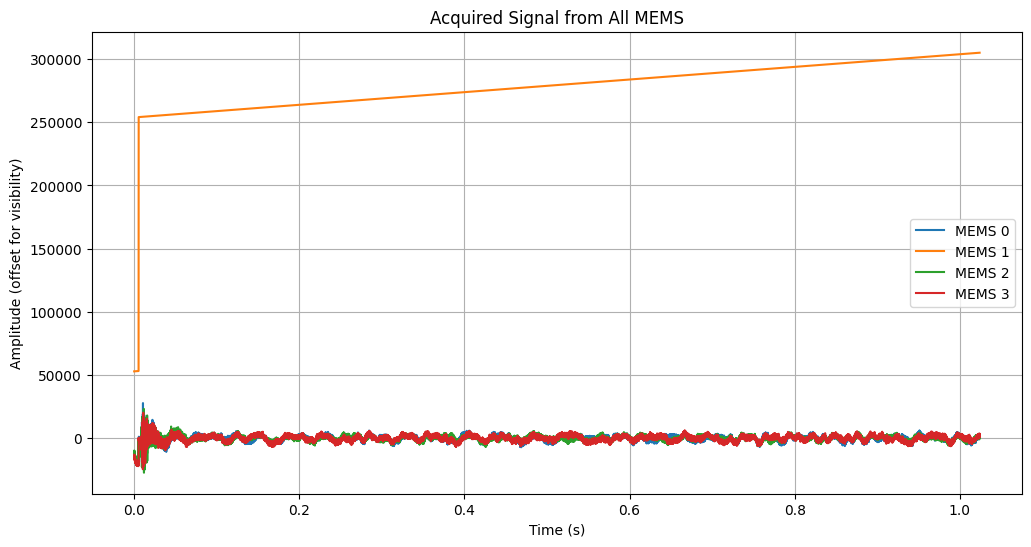

In [5]:
# Create configuration object
config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    sampling_frequency=50000,
    frame_length=1024,
    duration=1.0,
    timeout=10,
    trigger_start='trig1', 
    trigger_start_mode='rising',
    trigger_stop='trig1',
    trigger_stop_mode='rising'
)

# Use configuration (unpack dict)
try:
    antenna.run(**config.__dict__)

    # Collect signal
    frames = []
    for frame in antenna:
        frames.append(frame)

    antenna.wait()
    antenna.stop()

    # Concatenate all frames
    signal = np.concatenate(frames, axis=1)[1:,:]  # Skip counter row

    # Display signal
    plot_signal(signal, config.sampling_frequency)
    
except Exception as e:
    log.error(f"An error occurred during acquisition: {e}")

## Triggering with usb source

Same as before using the UsbSource low level library (see Notebook 02).

Let us assume we are using a Mµ32 device (0xAC03). First declare the source:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.sources import UsbDataSource
from megamicros.core.config import AcquisitionConfig, UsbConfig
from notebooks_tools import plot_signal

# Set log level to INFO to see device detection details
log.setLevel("INFO")

VENDOR_ID = 0xFE27
PRODUCT_ID = 0xAC03  # Example: Mu32-usb3 (OxAC03) / Mµ64-usb3 (OxAC04) /Mu256-usb3 (0xAC01)

usb_config = UsbConfig(vendor_id=VENDOR_ID, product_id=PRODUCT_ID)
source = UsbDataSource(usb_config)

2026-04-23 11:29:59,974 [INFO]: UsbDataSource initialized: 64 MEMS available
2026-04-23 11:29:59,977 [INFO]: USB device released and closed
2026-04-23 11:29:59,978 [INFO]:  .USB object destroyed


Configure the source with trigger_start='soft'. This is the default which means that the acquisition is soft triggered:  

2026-04-23 11:30:02,955 [INFO]: Connecting to USB device fe27:ac04 ...
2026-04-23 11:30:02,960 [INFO]: Connected on USB device fe27:ac04
2026-04-23 11:30:02,961 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-23 11:30:02,963 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-23 11:30:02,964 [INFO]: Sampling frequency 50000Hz sent as clockdiv 9 (nearest activated frequency is 50000Hz)
2026-04-23 11:30:02,966 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-23 11:30:02,967 [INFO]: Datatype sent to FPGA: int32
2026-04-23 11:30:02,967 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-23 11:30:02,968 [INFO]: Starting USB acquisition...
2026-04-23 11:30:02,969 [INFO]: START command sent to FPGA (trigger: soft, mode: N/A)
2026-04-23 11:30:02,969 [INFO]: Starting native USB async bulk transfer (duration=1.0s, expected frames=49)
2026-04-23 11:30:02,970 [INFO]: Init asynchronous bulk transfer...
2026-04-23 11:3

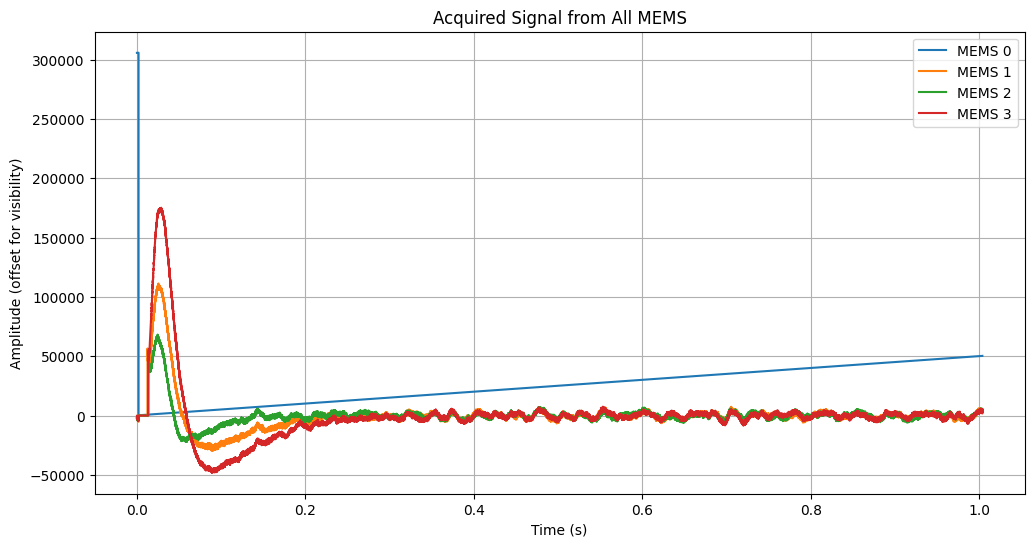

In [4]:
# Create configuration object
config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    sampling_frequency=50000,
    frame_length=1024,
    duration=1.0,
    trigger_start='soft', 
)

try: 
    frames = []
    source.configure(config)
    source.start()
            
    # Collect frames in a list    
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()

    # Concatenate all frames
    signal = np.concatenate(frames, axis=1)[1:,:]  # Skip counter row

    # Display signal
    plot_signal(signal, config.sampling_frequency)

except Exception as e:
    print(f"Error during acquisition: {e}")

Now set the `trigger_start` to `trig1`. At start you shoudl see the `ATT. TRIG` red led lighting on the device. 
It means that the device is expecting a TTL trigger signal on the `TRIG` 

2026-04-23 11:30:18,638 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-23 11:30:18,640 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,640 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,641 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,641 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,641 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,642 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,642 [INFO]: USB callback: transfer cancelled
2026-04-23 11:30:18,644 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-23 11:30:18,645 [INFO]: Sampling frequency 50000Hz sent as clockdiv 9 (nearest activated frequency is 50000Hz)
2026-04-23 11:30:18,647 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-23 11:30:18,648 [INFO]: Datatype sent to FPGA: int32
2026-04-23 11:30:18,648 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-23 11:30:1

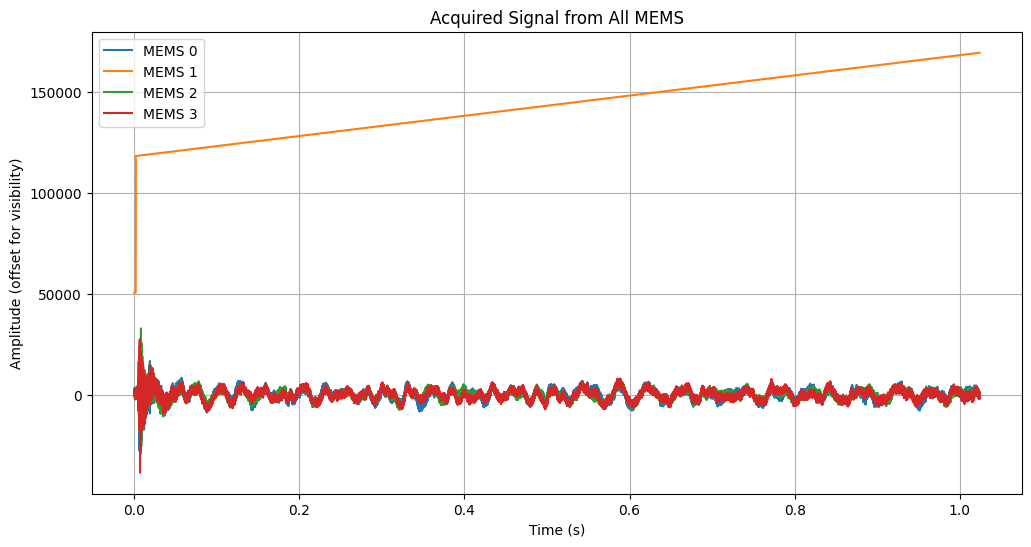

In [5]:
# Create configuration object
config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    sampling_frequency=50000,
    frame_length=1024,
    duration=1.0,
    timeout=10,
    trigger_start='trig1',
    use_direct_transfer=True
)

try: 
    frames = []
    source.configure(config)
    source.start()
            
    # Collect frames in a list    
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()

    # Concatenate all frames
    signal = np.concatenate(frames, axis=1)[1:,:]  # Skip counter row

    # Display signal
    plot_signal(signal, config.sampling_frequency)

except Exception as e:
    print(f"Error during acquisition: {e}")

If you do not set the `trigger_start_mode`, the default is `rising`. But you can choose among `rising`, `failing`, `high`, `low`.

The acquisition time set by the `duration` parameter is applied upon receipt of the `TRIG` signal. 
If the `TRIG` signal never arrives, the device remains in a permanent waiting state.
This wait can be limited using the `timeout` configuration parameter. 
In the following example, a 1-second acquisition is initiated upon receipt of the `TRIG` signal within a 60-second interval.
If this interval is exceeded, the acquisition process is stopped without any signal frames being 

In [ ]:
# Create configuration object
config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    sampling_frequency=50000,
    frame_length=1024,
    duration=1.0,
    timeout=10,
    trigger_start='trig1',
    trigger_start_mode='rising'
)

try: 
    frames = []
    source.configure(config)
    source.start()
            
    # Collect frames in a list    
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()

    # Concatenate all frames
    if len(frames) == 0:
        raise ValueError("No frames acquired. Check trigger and acquisition settings.")
    
    signal = np.concatenate(frames, axis=1)[1:,:]  # Skip counter row

    # Display signal
    plot_signal(signal, config.sampling_frequency)

except Exception as e:
    print(f"Error during acquisition: {e}")



## Stop Triggering

By setting up the `trigger_stop` and `trigger_stop_mode` parameters you can also stop the acquisition by sending a TTL signal on the TRIG device entry.
The `duration` value ensure the device performs at least `duration` seconds of acquisition. After this duration delay, the device continue with acquisition until you set a TTL signal on the TRIG entry:  

2026-04-23 11:32:57,547 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-23 11:32:57,552 [INFO]: USB callback: transfer cancelled
2026-04-23 11:32:57,552 [INFO]: USB callback: transfer cancelled
2026-04-23 11:32:57,553 [INFO]: USB callback: transfer cancelled
2026-04-23 11:32:57,553 [INFO]: USB callback: transfer cancelled
2026-04-23 11:32:57,554 [INFO]: USB callback: transfer cancelled
2026-04-23 11:32:57,554 [INFO]: USB callback: transfer cancelled
2026-04-23 11:32:57,556 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-23 11:32:57,557 [INFO]: Sampling frequency 50000Hz sent as clockdiv 9 (nearest activated frequency is 50000Hz)
2026-04-23 11:32:57,558 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-23 11:32:57,559 [INFO]: Datatype sent to FPGA: int32
2026-04-23 11:32:57,559 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-23 11:32:57,560 [INFO]: Starting USB acquisition...
2026-04-23 11:32:57,561

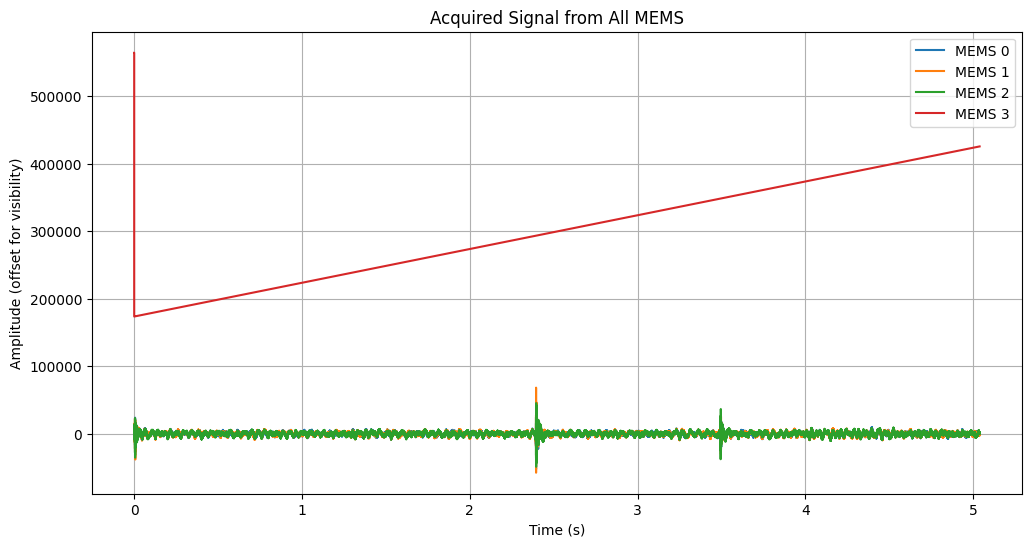

In [ ]:
# Create configuration object

# duration: The device performs an automatic stop after this duration unless a trigger is configured to stop it later. 
# timeout: The time to wait for the first frame after starting acquisition before giving up and raising an error. 
#   Should be long enough to allow for trigger setup and response time, but not too long to delay error detection in case of misconfiguration. 
#   Adjust as needed based on expected trigger response times and system performance.

config = AcquisitionConfig(
    mems=[0, 1, 2, 3],
    sampling_frequency=50000,
    frame_length=1024,
    duration=1.0,                   
    timeout=10,
    trigger_start='trig1',
    trigger_start_mode='rising',
    trigger_stop='trig1',
    trigger_stop_mode='rising'
)

try: 
    frames = []
    source.configure(config)
    source.start()
            
    # Collect frames in a list    
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()

    # Concatenate all frames
    if len(frames) == 0:
        raise ValueError("No frames acquired. Check trigger and acquisition settings.")
    
    signal = np.concatenate(frames, axis=1)[1:,:]  # Skip counter row

    # Display signal
    plot_signal(signal, config.sampling_frequency)

except Exception as e:
    print(f"Error during acquisition: {e}")